# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [50]:
import os

print("1. Thư mục Python đang đứng:", os.getcwd())
print("2. Các file/thư mục xung quanh nó:")
for item in os.listdir():
    print(f"   - {item}")

1. Thư mục Python đang đứng: c:\Users\LENOVO\OneDrive - VNU-HCMUS\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw
2. Các file/thư mục xung quanh nó:
   - data
   - numpy_pandas_eda_hw.ipynb
   - README.md


In [51]:
STUDENT_NAME = "Phạm Gia Thư"  
STUDENT_ID = "25280046"  

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phạm Gia Thư (25280046)


In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\LENOVO\OneDrive - VNU-HCMUS\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [53]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [54]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

In [55]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [56]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [57]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)
# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [58]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [59]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [60]:
# TODO N3

correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)

review_mask = np.logical_and(~correct_mask, high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [61]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [62]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. Ký hiệu missing value trong CSV là kí tự '?'
3. Ý nghĩa của symboling: Mức đánh giá rủi ro bảo hiểm của xe ( từ -3 đến 3)

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [63]:
# TODO D1

raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

In [64]:
print(raw_df.shape)
raw_df.head()

(205, 26)


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [65]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [66]:
# TODO D2

df_clean = raw_df.replace("?", np.nan).copy()
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isnull().sum()

print("Missing values by column:")
print(missing_by_column)

Missing values by column:
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

Nhận xét

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì sẽ làm lệch thước đo và đơn vị. Ví dụ numd_doors(tính bằng cái, dao động khoảng 2-4), horsepower(trên 100). Nếu fill bừa tất cả bằng số 2, nó phù hợp với num_doors nhưng không phù hợp với horsepower về mặt vật lí. Nó còn làm thay đổi phân phổi và phá vỡ mối tương quan giữa các features.

- Với 'price' lựa chọn drop phù hợp hơn. Bởi vì:
    - Khi train model, price là output, nếu fill đồng nghĩa với việc đưa dữ liệu giả vào để dạy model. 
    - Dựa vào bảng trên, cột 'price' chỉ có 4 dòng miss / 205 dòng (khoảng 2%), drop không làm model thiếu dữ liệu để học và không làm mất đi tính tổng quan của dataset, mà lại đảm bảo 100% dữ liệu dùng để train là chính xác => Model dự đoán chuẩn hơn

- 'normalize_losses'(mức tổn thất bảo hiểm trung bình đã chuẩn hóa) thiếu 41 giá trị / 205 giá trị (~20%), gây các ảnh hưởng sau:
    - Nếu xóa sẽ gây mất dữ liệu => Dataset bị thu hẹp
    - Khó khăn trong việc xử lí: 
        - Nếu xóa, dataset bị thu hẹp
        - Nếu fill bằng mean/median tổng sẽ làm giá trị cột này mất đi tính tự nhiên do lượng xe bị giả quá lớn

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [67]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [68]:
# TODO D3

analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

In [69]:
print("X_auto_scaled shape:", X_auto_scaled.shape)
X_auto_scaled

X_auto_scaled shape: (199, 6)


array([[-0.01548585,  0.07625546,  0.20296699, -0.65277647, -0.53912772,
         0.03160942],
       [-0.01548585,  0.07625546,  0.20296699, -0.65277647, -0.53912772,
         0.40918671],
       [ 0.51484142,  0.60449348,  1.35087746, -0.96354805, -0.68549391,
         0.40918671],
       ...,
       [ 0.87932089,  1.10872067,  0.81696561, -1.11893383, -1.12459248,
         1.03555038],
       [ 1.27465576,  0.43641775,  0.06948903,  0.12415246, -0.53912772,
         1.15931531],
       [ 0.97574403,  0.34037447,  0.28305377, -0.96354805, -0.8318601 ,
         1.17879101]], shape=(199, 6))

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [70]:
# TODO D4
price_index = X_auto[:, 5]
price_z = (price_index - np.mean(price_index)) / np.std(price_index)
price_outlier_mask = np.abs(price_z) > 2
price_outliers = price_index[price_outlier_mask]

In [71]:
print(price_outliers)

[30760. 41315. 36880. 32250. 35550. 36000. 31600. 34184. 35056. 40960.
 45400. 32528. 34028. 37028.]


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [72]:
# TODO D5
engine_price_corr = analysis_df['engine_size'].corr(analysis_df['price'])
price_by_body_style = analysis_df.groupby('body_style')['price'].mean()

In [73]:
print("Hệ số tương quan giữa engine_size và price:", engine_price_corr)
print("Giá trung bình theo kiểu body_style: ")
print(price_by_body_style)

Hệ số tương quan giữa engine_size và price: 0.8738869517981518
Giá trung bình theo kiểu body_style: 
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

## M2.1 Price phân phối như thế nào?

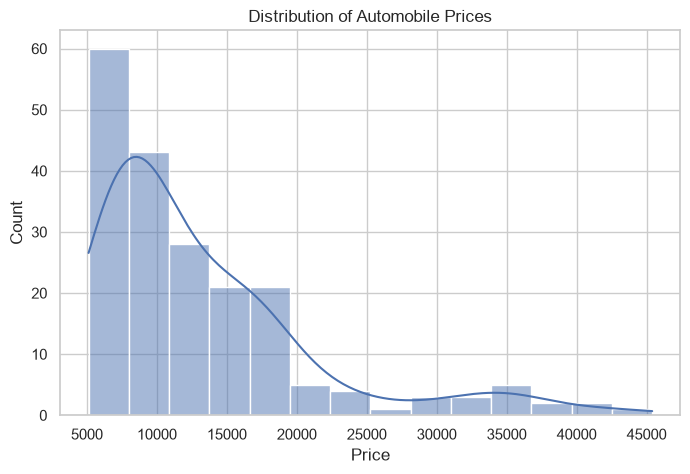

In [75]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 5))
sns.histplot(data = analysis_df, x='price', kde=True)

plt.title("Distribution of Automobile Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

**Nhận xét:** 

- Phân phối gia xe bị lệch phải
- Đa số các mẫu xe tập trung ở phân khúc giá thấp đến trung bình (đỉnh đồ thị nằm bên trái). Tuy nhiên trong dataset có các mẫu xe sang nên đồ thị bị kéo dài về phía bên phải ==> Mean > Median

## M2.2 Dataset có cân bằng theo body style không?

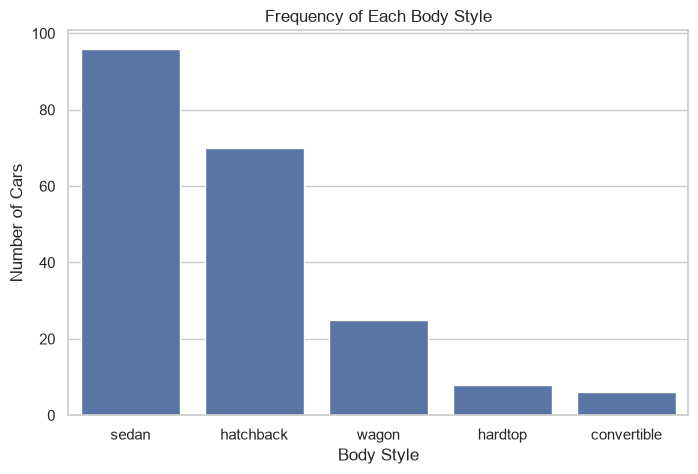

In [76]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))
sns.countplot(data = df_clean , x='body_style', order=df_clean['body_style'].value_counts().index)

plt.title('Frequency of Each Body Style')
plt.xlabel('Body Style')
plt.ylabel('Number of Cars')
plt.show()

**Nhận xét:**

- Dataset không cân bằng theo Body Style
- Cụ thể Sedan chiếm số lượng lớn nhất (gần 50%), hatchback ít hơn sedan nhưng số lượng vẫn áp đảo. Trong khi đó hardtop, convertible rất ít ==> Phản ánh thị trường tiêu dùng xe năm 1985 tại địa điểm thu thập dữ liệu

## M2.3 Price khác nhau theo body style ra sao?

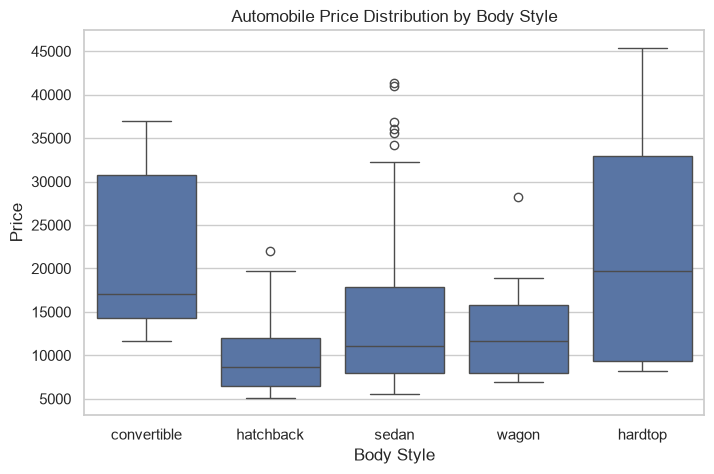

In [77]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8,5))
sns.boxplot(data = df_clean, x='body_style', y='price')

plt.title('Automobile Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price')
plt.show()


**Nhận xét:** 

- Dòng xe Convertible hoặc Hardtop dù số lượng ít (đã biết ở M2.2) nhưng hộp dữ liệu nằm ở vị trí rất cao, chứng tỏ giá trị phân khúc cao cấp hơn hẳn so với Hatchback hay Sedan.
- Outliers hầu như chỉ xuất hiện ở phía trên (phân khúc giá cao) của các nhóm xe phổ thông như Sedan hoặc Hatchback.

## M2.4 Engine size liên quan thế nào tới price?

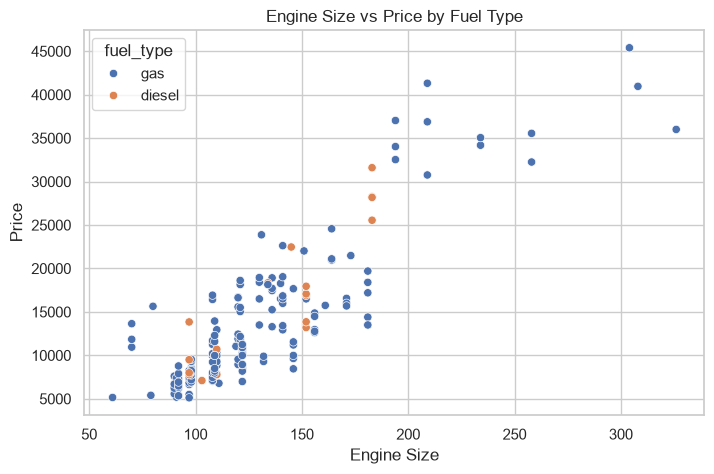

In [78]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8,5))
sns.scatterplot(data = df_clean, x='engine_size', y='price', hue='fuel_type')

plt.title('Engine Size vs Price by Fuel Type')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

**Nhận xét:** 

- Các chấm dữ liệu có xu hướng đi lên từ trái sang phải ==> động cơ càng lớn thì giá xe càng đắt (tương quan dương mạnh). Việc thêm fuel_type giúp nhìn thêm xem xe chạy dầu (diesel) hay chạy xăng (gas) có xu hướng đắt hơn ở cùng một mức dung tích động cơ hay không

## M2.5 Các feature numeric tương quan ra sao?

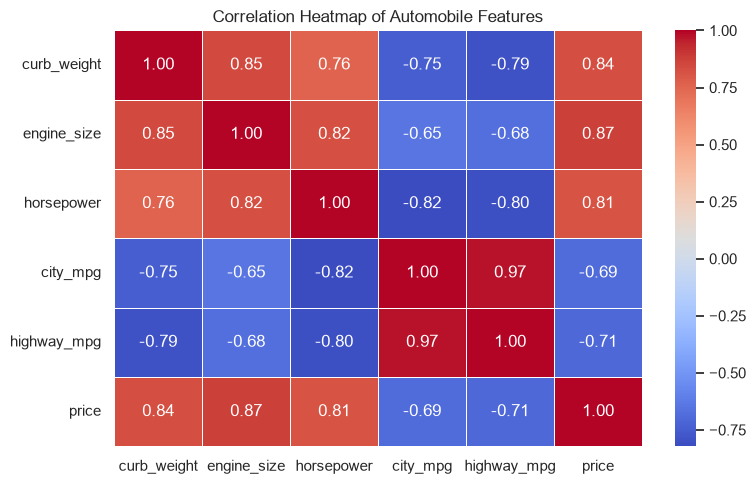

In [79]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(analysis_df[AUTO_FEATURES].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Automobile Features')
plt.tight_layout()
plt.show()

**Nhận xét:** 

- Các ô có màu đỏ đậm (hoặc hệ số gần 1.0) như engine_size, horsepower, curb_weight là các yếu tố quyết định lớn nhất đến giá xe
- Ngược lại, các cột như city_mpg hay highway_mpg sẽ có hệ số âm (màu xanh dương đậm), thể hiện tương quan âm ==> Xe càng đắt, động cơ càng lớn thì càng tốn xăng (số mile giảm)

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

**So sánh mức mã lực(horsepower) trung bình giữa các hãng xe(make) khác nhau**

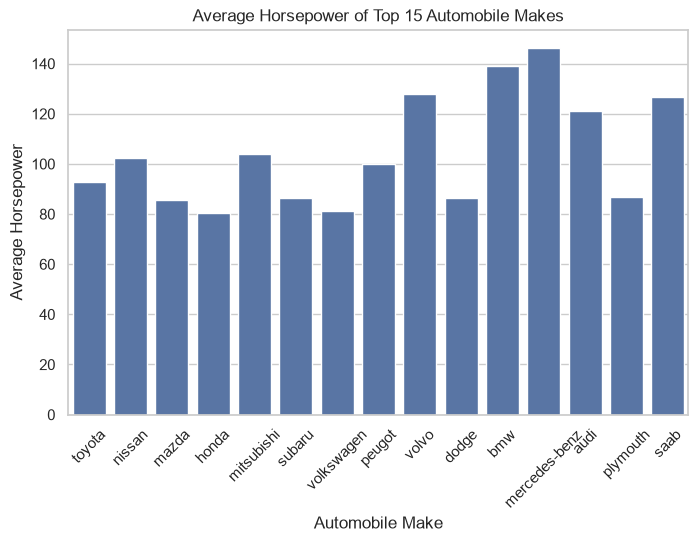

In [80]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(8,5))

top_makes = df_clean['make'].value_counts().head(15).index
filtered_df = df_clean[df_clean['make'].isin(top_makes)]

sns.barplot(data=filtered_df, x='make', y='horsepower', errorbar=None, order=top_makes)

plt.title('Average Horsepower of Top 15 Automobile Makes')
plt.xlabel('Automobile Make')
plt.ylabel('Average Horsepower')
plt.xticks(rotation=45)
plt.show()

**Nhận xét:** 

- Xe hãng Mercedes-benz có mã lực lớn nhất, ngược lại Honda, Volkswagen có mã lực thấp nhất
- Các xe đều có mã lực khoảng 80 trở lên

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên


**Dựa trên số liệu, biểu đồ phía trên, em có một số phát hiện sau:**
1. Giá xe bị phân hóa mạnh và tập trung ở phân khúc bình dân
    Từ histogram (M2.1) phân phối price lệch phải nặng. Phần lớn các xe tập trung ở dải giá thấp từ 5K-15K USD. Phần kéo dài 35K-45K là các dòng xe hạng sang (outliers)

2. Kích thước động cơ (engine_size), mã lực (horsepower), trọng lượng (curb_weight) quyết định giá xe
    Ma trận tương quan nhiệt Heatmap (M2.5) và Scatter plot (M2.4) cho thấy price có mối tương quan dương mạnh với engine_size, horsepower và curb_weight (hệ số tương quan thường đạt > 0.80) 
    ==> Động cơ càng to, xe càng nặng thì giá bán càng đắt.
    
3. Phân khúc giá có sự khác biệt rõ theo kiểu dáng xe (Body Style)
    Kết quả GroupBy (D5) và Boxplot (M2.3) cho thấy các dòng xe convertible và hardtop có mức giá trung bình cao vượt trội và dải giá rộng. Ngược lại, xe dáng hatchback có giá trung bình thấp nhất.


**Hạn chế**

1. Dữ liệu bị thiếu nghiêm trọng ở cột quan trọng là cột normalize_losses
    Cụ thể thiếu gần 20% dataset ==> Hạn chế khả năng phân tích mỗi quan hệ giữa mức độ rủi ro bảo hiểm(normalize_losses) với giá xe (price)

2. Hiện tượng đa cộng tuyến
    Khi quan sát ma trận tương quan nhiệt Heatmap (M2.5), curb_weight, engine_size, horsepower, length, width có hệ số tương quan thuận với nhau cực kỳ cao (thường từ 0.75 đến hơn 0.90).
    
3. Định dạnh dữ liệu chưa tối ưu
    Cụ thể cột num_of_doors bản chất là dạng số nhưng đang lưu ở dạng chữ ("two", "four",..)

**Ví dụ về correclation không đồng nghĩa với causation**

Ví dụ: Heatmap (M2.5) cho thấy biến wheel_base có mối tương quan dương khá cao với price

- Correlation: wheel_base (khoảng cách giữa 2 bánh xe) càng lớn thì giá càng cao
- Causation: Thực tế, wheel_base không phải là nguyên nhân khiến giá xe cao hơn. Nguyên nhân thực sự khiến giá xe cao nằm ở kiểu dáng xe sang trọng (body_style), hãng xe (make), kích thước động cơ lớn (engine_size) ==> bắt buộc wheel_base tăng. Do đó phân khúc xe sang và kích thước động cơ mới là nguyên nhân chính dẫn đến chiều dài cơ sở dài hơn và giá xe đắt hơn.

Có thể áp dụng các kỹ thuật Gom cụm (Clustering) hoặc phân loại nâng cao để tự động phân nhóm các mẫu xe thành các phân khúc cụ thể (Ví dụ: Xe giá rẻ, Xe gia đình phổ thông, Xe thể thao, Xe hạng sang) dựa trên sự kết hợp giữa các feature (engine_size, horsepower, fuel_type) và kiểu dáng (body_style) trước khi đưa vào mô hình dự đoán giá hay không?